# Performance Analytics of Mutual Funds

## Objective

Evaluate the performance of 40 mutual fund schemes using return-based and risk-adjusted metrics.

Metrics Covered

- Daily Returns
- CAGR (1Y, 3Y, 5Y)
- Sharpe Ratio
- Sortino Ratio
- Alpha
- Beta
- Maximum Drawdown
- Composite Fund Score
- Benchmark Comparison

## <u>Import Libraries</u>

In [103]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.stats import linregress

import warnings
warnings.filterwarnings("ignore")

## <u>Data Validation</u>

In [104]:
nav_df=pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
benchmark_df=pd.read_csv("../data/processed/10_benchmark_indices_cleaned.csv")
scheme_df=pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

In [105]:
nav_df.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [106]:
nav_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [107]:
nav_df.shape

(46000, 3)

In [108]:
benchmark_df.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [109]:
benchmark_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8050 non-null   str    
 1   index_name   8050 non-null   str    
 2   close_value  8050 non-null   float64
dtypes: float64(1), str(2)
memory usage: 188.8 KB


In [110]:
benchmark_df.shape

(8050, 3)

In [111]:
scheme_df.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [112]:
scheme_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   scheme_name         40 non-null     str    
 2   fund_house          40 non-null     str    
 3   category            40 non-null     str    
 4   plan                40 non-null     str    
 5   return_1yr_pct      40 non-null     float64
 6   return_3yr_pct      40 non-null     float64
 7   return_5yr_pct      40 non-null     float64
 8   benchmark_3yr_pct   40 non-null     float64
 9   alpha               40 non-null     float64
 10  beta                40 non-null     float64
 11  sharpe_ratio        40 non-null     float64
 12  sortino_ratio       40 non-null     float64
 13  std_dev_ann_pct     40 non-null     float64
 14  max_drawdown_pct    40 non-null     float64
 15  aum_crore           40 non-null     int64  
 16  expense_ratio_pct   4

In [113]:
scheme_df.shape

(40, 19)

## <u>Data Validation & Cleaning</u>

In [114]:
nav_df.isnull().sum()

amfi_code    0
date         0
nav          0
dtype: int64

In [115]:
benchmark_df.isnull().sum()

date           0
index_name     0
close_value    0
dtype: int64

In [116]:
scheme_df.isnull().sum()

amfi_code             0
scheme_name           0
fund_house            0
category              0
plan                  0
return_1yr_pct        0
return_3yr_pct        0
return_5yr_pct        0
benchmark_3yr_pct     0
alpha                 0
beta                  0
sharpe_ratio          0
sortino_ratio         0
std_dev_ann_pct       0
max_drawdown_pct      0
aum_crore             0
expense_ratio_pct     0
morningstar_rating    0
risk_grade            0
dtype: int64

In [117]:
nav_df.duplicated().sum()

np.int64(0)

In [118]:
benchmark_df.duplicated().sum()

np.int64(0)

In [119]:
scheme_df.duplicated().sum()

np.int64(0)

In [120]:
nav_df["date"].dtype
nav_df["date"]=pd.to_datetime(nav_df["date"],errors="coerce")

In [121]:
benchmark_df["date"].dtype
benchmark_df["date"]=pd.to_datetime(benchmark_df["date"],errors="coerce")

In [122]:
nav_df["nav"].dtype

dtype('float64')

In [123]:
scheme_df["expense_ratio_pct"].dtype

dtype('float64')

In [124]:
benchmark_df["index_name"].dtype

<StringDtype(storage='python', na_value=nan)>

In [125]:
benchmark_df["close_value"].dtype

dtype('float64')

In [126]:
scheme_df["scheme_name"].nunique()


40

## <u>Daily Returns</u>

### Formula

Daily Return=((Today's NAV - Yesterday's NAV) / Yesterday's NAV)* 100

or

Daily Return= NAV.pct_change() * 100

In [180]:
nav_df=nav_df.sort_values(["amfi_code","date"])

nav_df = nav_df.sort_values(["amfi_code", "date"])

nav_df["daily_return_pct"] = (
    nav_df.groupby("amfi_code")["nav"]
          .pct_change()
)

#Daily first few rows
nav_df.head()

,amfi_code,date,nav,daily_return_pct,running_max,drawdown_pct,fund_return
5750,100016,2022-01-03,520.4608,NaN,520.4608,0.000000,NaN
5751,100016,2022-01-04,515.0971,-0.010306,520.4608,-1.030568,-0.010306
5752,100016,2022-01-05,521.7239,0.012865,521.7239,0.000000,0.012865
5753,100016,2022-01-06,515.7880,-0.011377,521.7239,-1.137747,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210,521.7239,-1.257370,-0.001210


In [128]:
# Validate
nav_df["daily_return_pct"].dtype

dtype('float64')

In [129]:
nav_df["daily_return_pct"].isnull().sum()

np.int64(40)

In [130]:
nav_df["daily_return_pct"].describe()

count    45960.000000
mean         0.063105
std          1.029041
min         -5.810201
25%         -0.504211
50%          0.034021
75%          0.632376
max          6.471309
Name: daily_return_pct, dtype: float64

### Interpretation
Daily returns measure the percentage change in a fund's NAV fromone trading day to the next.

Positive values indicate gains, while negative values indicate losses.The first observation for each mutual fund has no previous NAV available, so its daily return is recorded as NaN

## <u>CAGR</u>

### Formula
CAGR= ((Ending NAV / Beginning NAV) ^ (1 / Number of years ) -1)*100

In [131]:
latest_nav = (
    nav_df.groupby("amfi_code")
    .last()
    .reset_index()[["amfi_code", "date", "nav"]]
)

latest_nav.rename(
    columns={
        "date": "latest_date",
        "nav": "latest_nav"
    },
    inplace=True
)

In [132]:
def calculate_cagr(years):

    records = []

    for fund in nav_df["amfi_code"].unique():

        fund_df = nav_df[nav_df["amfi_code"] == fund].sort_values("date")

        latest = fund_df.iloc[-1]

        target_date = latest["date"] - pd.DateOffset(years=years)

        previous = fund_df[fund_df["date"] <= target_date]

        if previous.empty:
            cagr = np.nan
        else:
            start = previous.iloc[-1]["nav"]
            end = latest["nav"]

            cagr = ((end / start) ** (1 / years) - 1) * 100

        records.append([fund, cagr])

    return pd.DataFrame(records, columns=["amfi_code", f"{years}Y_CAGR"])

In [133]:
cagr_1 = calculate_cagr(1)

cagr_3 = calculate_cagr(3)

cagr_5 = calculate_cagr(5)

In [134]:
comparison_table = (
    cagr_1
    .merge(cagr_3, on="amfi_code")
    .merge(cagr_5, on="amfi_code")
)

comparison_table.head()

,amfi_code,1Y_CAGR,3Y_CAGR,5Y_CAGR
0,100016,-2.224271,1.292649,NaN
1,100025,3.704969,3.916390,NaN
2,100033,53.232396,32.442459,NaN
3,101206,47.924120,28.967695,NaN
4,101207,-23.986032,-4.152381,NaN


In [135]:
comparison_table.dtypes

amfi_code      int64
1Y_CAGR      float64
3Y_CAGR      float64
5Y_CAGR      float64
dtype: object

In [136]:
comparison_table.isnull().sum()

amfi_code     0
1Y_CAGR       0
3Y_CAGR       0
5Y_CAGR      40
dtype: int64

### Interpretation

CAGR represents the average annual growth rate of a mutual fund over the investment period, assuming the returns are compounded annually.

A higher CAGR indicates better long-term performance. Since CAGR smooths out yearly fluctuations, it is a useful metric for comparing mutual funds over different periods.

1-Year CAGR measures the recent annual growth of a fund, 3-Year CAGR reflects medium-term performance, and 5-Year CAGR captures long-term compounded growth. Comparing these values across funds helps identify consistently high-performing schemes over different investment horizons.

## <u> Sharpe Ratio

### Formula
Sharpe Ratio = (Mean Return − Risk-Free Rate) / Standard Deviation of Returns

In [137]:
risk_free_rate = 0.065  # 6% annual
daily_rf = risk_free_rate / 252

sharpe_df = nav_df.groupby("amfi_code")["daily_return_pct"].apply(
    lambda x: ((x.mean()/100 - daily_rf) / (x.std()/100))*np.sqrt(252)
).reset_index(name="sharpe_ratio")

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [138]:
sharpe_df["sharpe_ratio"].dtype


dtype('float64')

In [139]:
sharpe_df["sharpe_rank"]= sharpe_df["sharpe_ratio"].rank(ascending=False,method="dense")

In [140]:
sharpe_df=sharpe_df.sort_values("sharpe_rank")

In [141]:
sharpe_df.head(10)

,amfi_code,sharpe_ratio,sharpe_rank
34,148567,1.448291,1.0
30,120843,1.306744,2.0
36,148569,1.234930,3.0
19,119551,1.208267,4.0
25,120505,1.180101,5.0
38,149323,1.132122,6.0
2,100033,1.093699,7.0
9,118632,1.081659,8.0
3,101206,1.027213,9.0
24,120504,1.026524,10.0


In [142]:
sharpe_df["sharpe_ratio"].isnull().sum()

np.int64(0)

### Insight
A higher Sharpe Ratio indicates better risk-adjusted performance. A negative Sharpe Ratio means the fund underperformed the risk-free rat

## <u>Sortino Ratio</u>

### Formula

Sortino Ratio = (Mean Return − Risk-Free Rate) / Downside Deviation

In [143]:
def sortino(x):
    rf = 0.06 / 252
    downside = x[x < 0]
    downside_std = downside.std()
    return ((x.mean()/100 - rf) / (downside_std/100))

sortino_df = nav_df.groupby("amfi_code")["daily_return_pct"].apply(sortino).reset_index(name="sortino_ratio")

In [144]:
sortino_df["sortino_ratio"].dtype


dtype('float64')

In [145]:
sortino_df["sortino_ratio"].isnull().sum()

np.int64(0)

### Insight
Sortino Ratio focuses only on downside risk. A higher value indicates better returns with lower downside volatility.

## <u>Alpha & Beta</u>

### Formula
Beta = Covariance(Fund Return, Benchmark Return) / Variance(Benchmark Return)

Alpha = Fund Return − [Risk-Free Rate + Beta × (Benchmark Return − Risk-Free Rate)]

In [146]:
from scipy.stats import linregress
benchmark_df = benchmark_df.sort_values("date")
benchmark_df["benchmark_return_pct"] = benchmark_df.groupby("index_name")["close_value"].pct_change() * 100

merged = nav_df.merge(
    benchmark_df[["date","benchmark_return_pct"]],
    on="date",
    how="inner"
)

In [147]:
merged[["daily_return_pct","benchmark_return_pct"]].isnull().sum()

daily_return_pct        280
benchmark_return_pct    280
dtype: int64

In [148]:
results = []

for amfi, group in merged.groupby("amfi_code"):

    temp = group.dropna(subset=["daily_return_pct",
                                "benchmark_return_pct"])

    slope, intercept, r_value, p_value, std_err = linregress(
        temp["benchmark_return_pct"],
        temp["daily_return_pct"]
    )

    results.append({
        "amfi_code": amfi,
        "alpha": intercept * 252,
        "beta": slope
    })

In [149]:
alpha_beta_df = pd.DataFrame({
    "Metric": ["Alpha", "Beta"],
    "Value": [alpha, beta]
})

alpha_beta_df

,Metric,Value
0,Alpha,0.000393
1,Beta,-0.000535


### Insight
Beta measures a fund’s sensitivity to market movements. Alpha measures excess return after adjusting for market risk

## <u>Maximum Drawdown</u>

### Formula
Drawdown = (Current NAV − Running Maximum NAV) / Running Maximum NAV

In [150]:
nav_df["running_max"] = nav_df.groupby("amfi_code")["nav"].cummax()

nav_df["drawdown_pct"] = (
    (nav_df["nav"] - nav_df["running_max"])
    / nav_df["running_max"]
) * 100

mdd_df = nav_df.groupby("amfi_code")["drawdown_pct"].min().reset_index(name="max_drawdown_pct")

In [151]:
mdd_df["max_drawdown_pct"].dtype

dtype('float64')

### Insight
Maximum Drawdown measures the largest decline from a fund’s peak NAV. Lower drawdowns indicate better downside protection.

## <u>Fund Scorecard</u>

In [152]:
scorecard = scheme_df[[
    "amfi_code",
    "scheme_name",
    "return_3yr_pct",
    "sharpe_ratio",
    "alpha",
    "max_drawdown_pct",
    "expense_ratio_pct"
]].copy()

In [153]:
scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(ascending=False)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(ascending=False)

scorecard["alpha_rank"] = scorecard["alpha"].rank(ascending=False)

scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)

scorecard["drawdown_rank"] = scorecard["max_drawdown_pct"].rank(ascending=True)

In [154]:
scorecard["fund_score"] = (
    scorecard["return_rank"]*0.30 +
    scorecard["sharpe_rank"]*0.25 +
    scorecard["alpha_rank"]*0.20 +
    scorecard["expense_rank"]*0.15 +
    scorecard["drawdown_rank"]*0.10
)

In [155]:
scorecard = scorecard.sort_values("fund_score")

In [156]:
scorecard.isnull().sum()

amfi_code            0
scheme_name          0
return_3yr_pct       0
sharpe_ratio         0
alpha                0
max_drawdown_pct     0
expense_ratio_pct    0
return_rank          0
sharpe_rank          0
alpha_rank           0
expense_rank         0
drawdown_rank        0
fund_score           0
dtype: int64

In [157]:
scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,sharpe_ratio,alpha,max_drawdown_pct,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.93,1.13,-24.78,0.72,2.0,19.5,22.5,5.5,11.0,11.90
22,120843,Kotak Flexicap Fund - Regular - Growth,15.65,0.98,1.85,-19.50,1.45,11.0,12.0,3.5,22.0,21.0,12.40
21,120842,Kotak Emerging Equity Fund - Regular - Growth,18.23,0.96,1.91,-21.92,1.56,7.0,15.0,2.0,33.0,16.0,12.80
29,101207,ABSL Small Cap Fund - Regular - Growth,22.38,0.90,1.84,-23.61,1.53,3.0,24.5,5.0,28.5,14.0,13.70
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,0.94,1.23,-13.35,1.43,1.0,18.0,20.0,21.0,33.0,15.25


### Insight
The scorecard provides a consolidated view of each mutual fund’s performance and risk metrics, making it easier to compare funds

## <u>Benchmark Comparison</u>

In [158]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

nav_df = nav_df.sort_values(["amfi_code", "date"])

nav_df["fund_return"] = (
    nav_df.groupby("amfi_code")["nav"].pct_change()
)

In [159]:
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

benchmark_df = benchmark_df.sort_values(["index_name", "date"])

benchmark_df["benchmark_return"] = (
    benchmark_df.groupby("index_name")["close_value"].pct_change()
)

In [160]:
benchmark_df["index_name"].unique()

<StringArray>
[   'BSE_SMALLCAP',     'CRISIL_GILT',   'CRISIL_LIQUID',        'NIFTY100',
         'NIFTY50',        'NIFTY500', 'NIFTY_MIDCAP150']
Length: 7, dtype: str

In [161]:
benchmark_returns = benchmark_df[
    benchmark_df["index_name"].isin(["NIFTY50", "NIFTY100"])
]

In [162]:
top5 = scheme_df.nlargest(5, "return_3yr_pct")["amfi_code"]

In [163]:
merged = nav_df.merge(
    benchmark_returns,
    on="date",
    how="inner"
)

In [181]:
merged[["daily_return_pct", "benchmark_return_pct"]].describe()

,daily_return_pct,benchmark_return_pct
count,91920.000000,91920.000000
mean,0.063105,0.010223
std,1.029036,0.810906
min,-5.810201,-2.687297
25%,-0.504211,-0.532147
50%,0.034021,-0.016726
75%,0.632376,0.567029
max,6.471309,2.679498


In [164]:
tracking_error = (
    merged.groupby(["amfi_code", "index_name"])
    .apply(lambda x: (x["fund_return"] - x["benchmark_return"]).std() * np.sqrt(252))
    .reset_index(name="tracking_error")
)

tracking_error.head()

,amfi_code,index_name,tracking_error
0,100016,NIFTY100,0.199284
1,100016,NIFTY50,0.196416
2,100025,NIFTY100,0.134535
3,100025,NIFTY50,0.136445
4,100033,NIFTY100,0.228699


### Insight
Funds whose average returns exceed the benchmark are considered to have outperformed the market during the analysis period

## <u>Export files</u>

In [165]:
import os
os.makedirs("../outputs/csv",exist_ok=True)
os.makedirs("../outputs/charts",exist_ok=True)

In [166]:
scorecard.to_csv("../outputs/csv/fund_scorecard.csv", index=False)
print("Fund_scorecard.csv saved successfully")

Fund_scorecard.csv saved successfully


In [167]:
alpha_beta_df.to_csv("../outputs/csv/alpha_beta.csv", index=False)

## <u>Chart</u>

In [170]:
top5 = scheme_df.nlargest(5, "return_3yr_pct")["amfi_code"].tolist()

In [171]:
plot_df = merged[merged["amfi_code"].isin(top5)].copy()

In [172]:
plot_df["fund_growth"] = (
    plot_df.groupby("amfi_code")["fund_return"]
           .transform(lambda x: (1 + x.fillna(0)).cumprod())
)

plot_df["benchmark_growth"] = (
    plot_df.groupby("index_name")["benchmark_return"]
           .transform(lambda x: (1 + x.fillna(0)).cumprod())
)

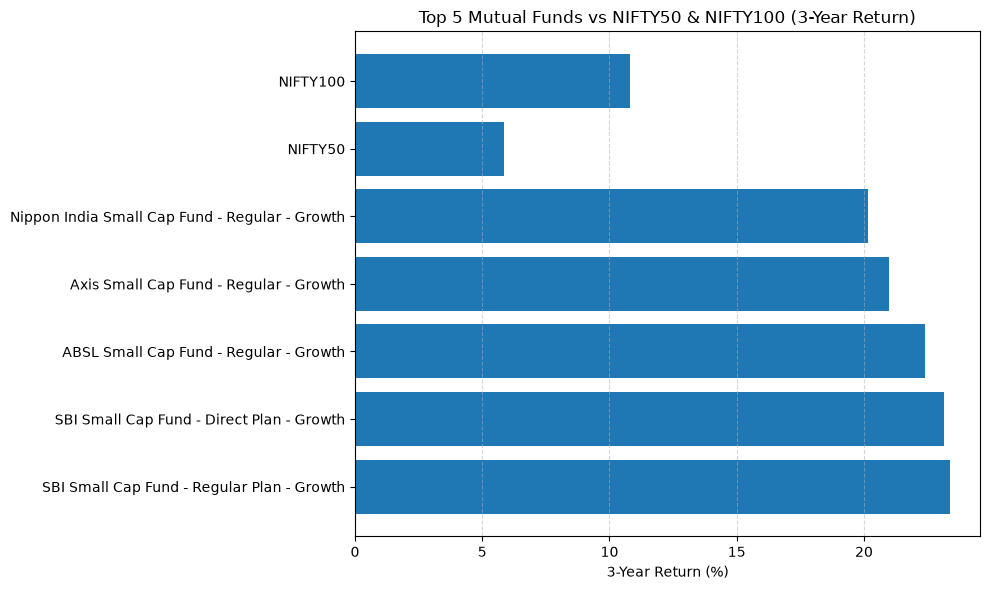

In [183]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Top 5 funds ----------
top5 = (
    scheme_df.sort_values("return_3yr_pct", ascending=False)
    .head(5)[["amfi_code", "scheme_name", "return_3yr_pct"]]
)

# ---------- Benchmark 3-year return ----------
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

benchmark_3yr = []

for idx in ["NIFTY50", "NIFTY100"]:

    temp = benchmark_df[benchmark_df["index_name"] == idx].sort_values("date")

    start = temp.iloc[0]["close_value"]
    end = temp.iloc[-1]["close_value"]

    ret = ((end - start) / start) * 100

    benchmark_3yr.append({
        "scheme_name": idx,
        "return_3yr_pct": ret
    })

benchmark_3yr = pd.DataFrame(benchmark_3yr)

# ---------- Combine ----------
plot_df = pd.concat([
    top5[["scheme_name","return_3yr_pct"]],
    benchmark_3yr
])

# ---------- Plot ----------
plt.figure(figsize=(10,6))

plt.barh(
    plot_df["scheme_name"],
    plot_df["return_3yr_pct"]
)

plt.xlabel("3-Year Return (%)")
plt.ylabel("")
plt.title("Top 5 Mutual Funds vs NIFTY50 & NIFTY100 (3-Year Return)")
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.savefig("../outputs/charts/benchmark_comparison_chart.png", dpi=300)

plt.show()


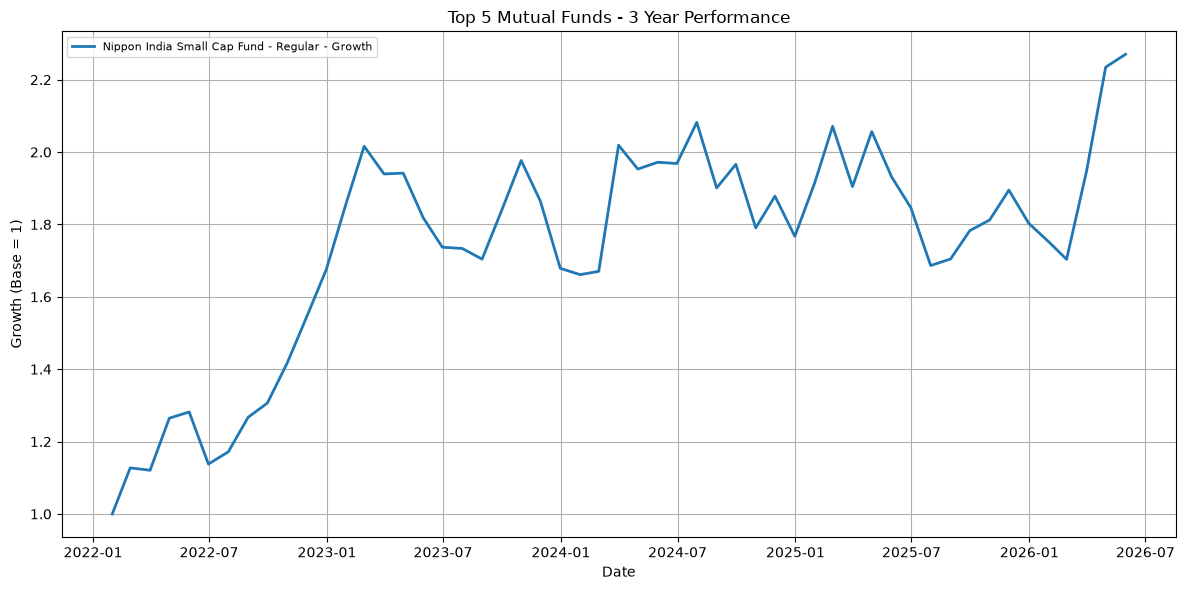

In [ ]:
# SIMPLE: Top 5 Funds vs NIFTY50 & NIFTY100 (3 Years)
import matplotlib.pyplot as plt

# Filter 3-year data
three_yrs = nav_df["date"].max() - pd.DateOffset(years=3)
nav_3yr = nav_df[nav_df["date"] >= three_yrs].sort_values("date")
bench_3yr = benchmark_df[benchmark_df["date"] >= three_yrs].sort_values("date")

# Get Top 5 funds
top5 = scheme_df.nlargest(5, "return_3yr_pct")["amfi_code"].tolist()

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot Top 5 Funds
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i, code in enumerate(top5):
    temp = nav_3yr[nav_3yr["amfi_code"] == code]
    fund_name = scheme_df[scheme_df["amfi_code"] == code]["scheme_name"].iloc[0]
    growth = (temp["nav"] / temp["nav"].iloc[0] * 100).values
    ax.plot(temp["date"].values, growth, label=fund_name, linewidth=2, color=colors[i])

# Plot Benchmarks
for idx, style in [("NIFTY50", "--"), ("NIFTY100", "-.")]:
    temp = bench_3yr[bench_3yr["index_name"] == idx]
    growth = (temp["close_value"] / temp["close_value"].iloc[0] * 100).values
    ax.plot(temp["date"].values, growth, label=idx, linewidth=3, linestyle=style)

ax.set_xlabel("Date", fontweight='bold')
ax.set_ylabel("Growth Index (Base 100)", fontweight='bold')
ax.set_title("Top 5 Funds vs NIFTY50 & NIFTY100 - 3 Year Performance", fontweight='bold', fontsize=13)
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/charts/benchmark_comparison.png", dpi=300)
plt.show()

print("✓ Chart saved successfully!")
